In [49]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.multioutput import MultiOutputRegressor

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import ParameterGrid
import shap


In [50]:
data_path = "../joined_features/full_dataset.csv"
df = pd.read_csv(data_path)
########## ---------- Convert into categorical ---------- ########## 
topic_cols = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11'
]

# find max column per row
max_cols = df[topic_cols].idxmax(axis=1)

# zero everything
df[topic_cols] = 0

# set the max column to 1
for col in topic_cols:
    df.loc[max_cols == col, col] = 1

# Remove rows with no posts (these can introduce NaNs)
df = df[df["post_count"] != 0]

# Basic NaN diagnostics
nan_count = df.isna().sum().sum()
print(f"Number of NaN values: {nan_count}")

if nan_count > 0:
    failing_cols = df.columns[df.isna().any()]
    print(f"Columns with NaN: {list(failing_cols)}")

Number of NaN values: 1
Columns with NaN: ['avg_text_len']


In [51]:
features = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11',
    'topic_activity_12', 'trump_sentiment_mean_x', 'trump_sentiment_std',
    'trump_sentiment_pct_negative', 
    'cpi', 
    'interest_rate', 
    'consumer_sentiment',
    'unemployment', 'news_sentiment_rolling', 'news_sentiment_mean_y',
]

predictors = [
    'avg_reblogs', 'avg_upvotes', 'total_upvotes'
]

df = df.sort_index()  # or: df = df.sort_values("date")
n = len(df)



train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

X_train = train[features]
Y_train = train[predictors]

X_val = val[features]
Y_val = val[predictors]

X_test = test[features]
Y_test = test[predictors]

In [52]:
models = {
    "random_forest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )
    ),

    "linear_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(LinearRegression()))
    ]),

    "svm": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(
            SVR(kernel="rbf", C=1.0)
        ))
    ]),

    "xgboost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        )
    ),

    "lightgbm": MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
    ),

    "mlp": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            max_iter=1000,
            random_state=42
        ))
    ])
}


In [53]:

def evaluate_model(name, model, X_train, Y_train, X_val, Y_val):
    model.fit(X_train, Y_train)

    preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(Y_val, preds))
    mae = mean_absolute_error(Y_val, preds)
    r2 = r2_score(Y_val, preds)

    return {
        "model_name": name,
        "model": model,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }


def run_all_models(models, X_train, Y_train, X_val, Y_val):
    results = []

    for name, model in models.items():
        print(f"Training {name}...")

        result = evaluate_model(
            name,
            model,
            X_train,
            Y_train,
            X_val,
            Y_val
        )

        results.append(result)

    results_df = pd.DataFrame(results).drop(columns=["model"])
    results_df = results_df.sort_values("rmse")

    return results, results_df

In [54]:
results, results_df = run_all_models(
    models,
    X_train,
    Y_train,
    X_val,
    Y_val
)

Training random_forest...
Training linear_regression...
Training svm...
Training xgboost...
Training lightgbm...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 209
[LightGBM] [Info] Number of data points in the train set: 102, number of used features: 12
[LightGBM] [Info] Start training from score 5726.186270
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

c:\Users\huste\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [55]:
df_results = pd.DataFrame(results)
df_results = df_results.drop(columns=["model"]) 
df_results = df_results.sort_values("rmse")

baseline_preds = Y_test.shift(1)

baseline_r2 = r2_score(Y_test.iloc[1:], baseline_preds.iloc[1:])

print("Baseline r2", baseline_r2)
df_results["improvement"] = df_results["r2"] - baseline_r2

print(df_results.sort_values("improvement", ascending=False))

Baseline r2 -0.45321030684875185
          model_name           rmse           mae        r2  improvement
0      random_forest  102774.062670  45939.027598  0.271179     0.724389
1  linear_regression  100536.442687  51426.368675  0.264539     0.717749
4           lightgbm  108345.435427  49932.150807  0.193113     0.646323
3            xgboost  111137.778275  45639.718750  0.133493     0.586703
2                svm  125717.874436  58331.648305 -0.089903     0.363307
5                mlp  161999.255700  81839.596561 -4.777032    -4.323821


Saved result from different ML models:

**Baseline R²:** -0.45321030684875185

| model_name        | rmse         | mae          | r2        | improvement |
|------------------|-------------:|-------------:|----------:|------------:|
| random_forest    | 102774.062670 | 45939.027598 | 0.271179  | 0.724389    |
| linear_regression| 100536.442687 | 51426.368675 | 0.264539  | 0.717749    |
| lightgbm         | 108345.435427 | 49932.150807 | 0.193113  | 0.646323    |
| xgboost          | 111137.778275 | 45639.718750 | 0.133493  | 0.586703    |
| svm              | 125717.874436 | 58331.648305 | -0.089903 | 0.363307    |
| mlp              | 161999.255700 | 81839.596561 | -4.777032 | -4.323821   |

**Results from differnt random trees** <br> We didn't keep the code, but we tried grid searching on different tree model, but we just used the current pipeline that we build, which evaluated based on traning data. If we want to do grid search we have to pick the hyperparameters based on the validation set.

**Baseline R²:** -0.4532

| model_name              | rmse     | mae      | r2     | improvement |
|------------------------|---------:|---------:|-------:|------------:|
| rf_d3_leaf5_feat0.5    | 96,461   | 42,613   | 0.346  | 0.799       |
| rf_d5_leaf5_feat0.5    | 99,164   | 42,861   | 0.336  | 0.790       |
| rf_d8_leaf5_feat0.5    | 99,365   | 42,821   | 0.333  | 0.786       |
| rf_d8_leaf10_feat0.5   | 97,189   | 43,232   | 0.302  | 0.755       |
| rf_d5_leaf10_feat0.5   | 97,189   | 43,232   | 0.302  | 0.755       |
| rf_d3_leaf10_feat0.5   | 96,990   | 43,205   | 0.301  | 0.754       |
| rf_d8_leaf5_featsqrt   | 99,694   | 45,685   | 0.274  | 0.727       |
| rf_d5_leaf5_featsqrt   | 100,412  | 46,061   | 0.273  | 0.726       |
| random_forest          | 102,774  | 45,939   | 0.271  | 0.724       |
| linear_regression      | 100,536  | 51,426   | 0.265  | 0.718       |
| rf_d3_leaf5_featsqrt   | 99,568   | 45,173   | 0.259  | 0.712       |
| rf_d8_leaf10_featsqrt  | 100,943  | 46,160   | 0.245  | 0.698       |

In [56]:
def diagnose_random_forest(
    model,
    X,
    Y,
    time_data=None,
    target_idx=0,
    alpha=None,
    lags=40,
    top_n=15,
    title=None
):
    """
    Diagnostic plots for RandomForest / MultiOutputRegressor(RandomForestRegressor).

    Produces:
    1. ACF of residuals
    2. QQ plot of residuals
    3. Feature importances
    4. Actual vs predicted over time
    """

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------
    y_pred = model.predict(X)

    if y_pred.ndim == 2:
        y_pred_target = y_pred[:, target_idx]
    else:
        y_pred_target = y_pred

    if isinstance(Y, pd.DataFrame):
        target_name = Y.columns[target_idx]
        y_true = Y.iloc[:, target_idx].values
    else:
        target_name = f"target_{target_idx}"
        y_true = np.asarray(Y)
        if y_true.ndim == 2:
            y_true = y_true[:, target_idx]

    residuals = y_true - y_pred_target

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_target))
    mae = mean_absolute_error(y_true, y_pred_target)
    r2 = r2_score(y_true, y_pred_target)

    print(f"Target: {target_name}")
    print(f"RMSE:   {rmse:.6f}")
    print(f"MAE:    {mae:.6f}")
    print(f"R2:     {r2:.6f}")

    # --------------------------------------------------------
    # Extract feature importances
    # --------------------------------------------------------
    if hasattr(model, "estimators_"):
        # MultiOutputRegressor
        rf = model.estimators_[target_idx]
    else:
        # Plain RandomForestRegressor
        rf = model

    importances = pd.Series(
        rf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    top_importances = importances.head(top_n).sort_values()

    # --------------------------------------------------------
    # Time handling
    # --------------------------------------------------------
    if time_data is None:
        time_data = pd.Series(X.index, index=X.index)
    else:
        time_data = pd.Series(time_data, index=X.index)

    time_data = pd.to_datetime(time_data, errors="coerce")

    plot_df = pd.DataFrame({
        "time": time_data,
        "actual": y_true,
        "predicted": y_pred_target,
        "residual": residuals
    }, index=X.index).dropna()

    # --------------------------------------------------------
    # Plotting
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # 1. ACF of residuals
    plot_acf(plot_df["residual"], lags=min(lags, len(plot_df) - 1), ax=axes[0])
    axes[0].set_title("ACF of Residuals")

    # 2. QQ plot
    sm.qqplot(plot_df["residual"], line="s", ax=axes[1])
    axes[1].set_title("QQ Plot of Residuals")

    # 3. Feature importances
    axes[2].barh(top_importances.index, top_importances.values)
    axes[2].set_title(f"Top {top_n} Feature Importances")
    axes[2].set_xlabel("Importance")

    # 4. Actual vs predicted over time
    axes[3].scatter(
        plot_df["time"],
        plot_df["actual"],
        alpha=0.5,
        label="Actual"
    )

    axes[3].plot(
        plot_df["time"],
        plot_df["predicted"],
        linewidth=2,
        label="Predicted"
    )

    axes[3].set_xlim(plot_df["time"].min(), plot_df["time"].max())

    locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
    formatter = mdates.DateFormatter("%Y-%m-%d")

    axes[3].xaxis.set_major_locator(locator)
    axes[3].xaxis.set_major_formatter(formatter)

    axes[3].set_title("Actual vs Predicted Over Time")
    axes[3].set_xlabel("Date")
    axes[3].set_ylabel(target_name)
    axes[3].legend()
    axes[3].tick_params(axis="x", rotation=45)

    if title is not None:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    return {
        "target": target_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "feature_importances": importances,
        "residuals": plot_df["residual"],
        "predictions": plot_df["predicted"],
        "actual": plot_df["actual"]
    }

Target: avg_reblogs
RMSE:   574.112757
MAE:    458.069049
R2:     0.889715


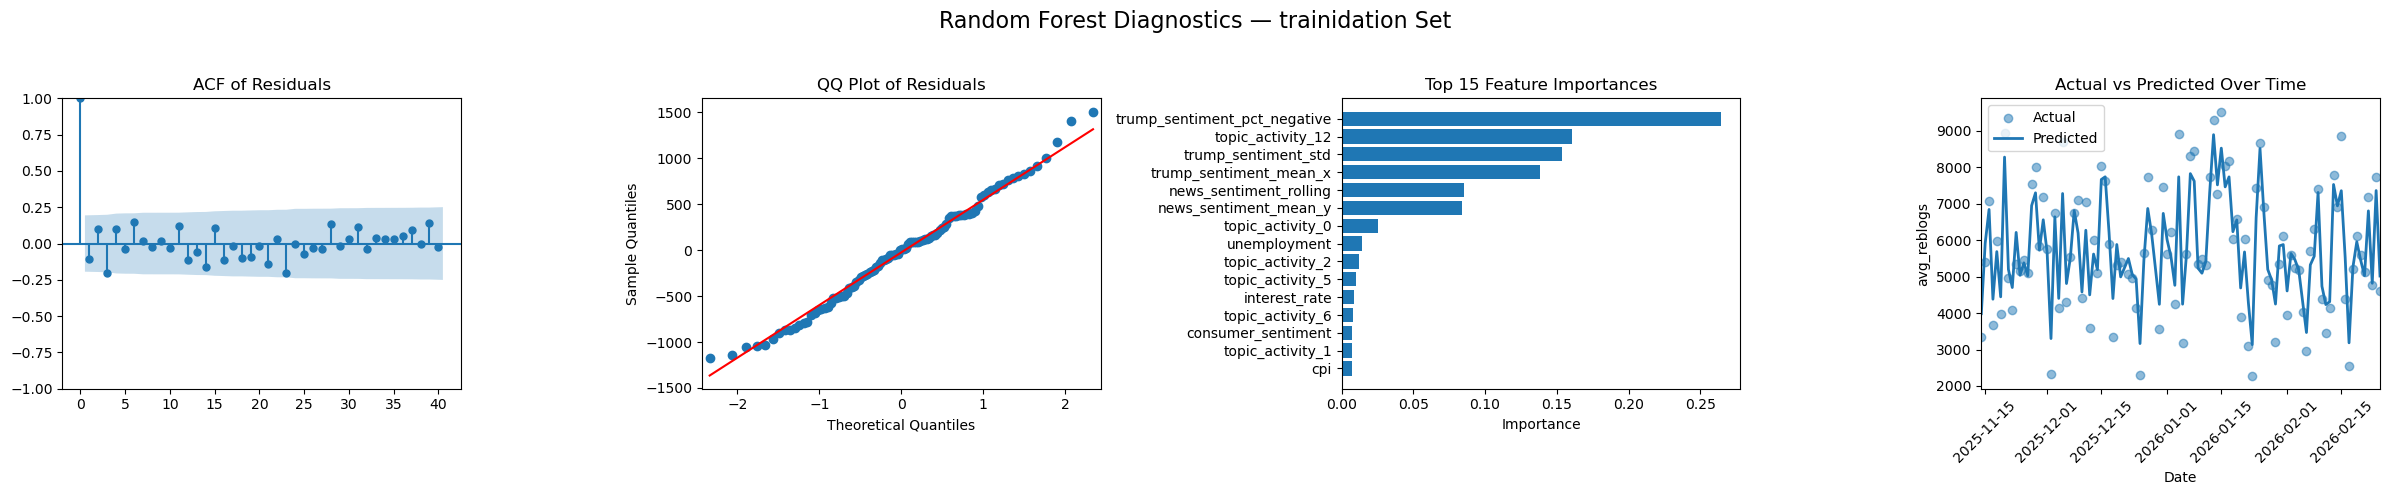

Target: avg_upvotes
RMSE:   2442.261764
MAE:    1931.909426
R2:     0.884101


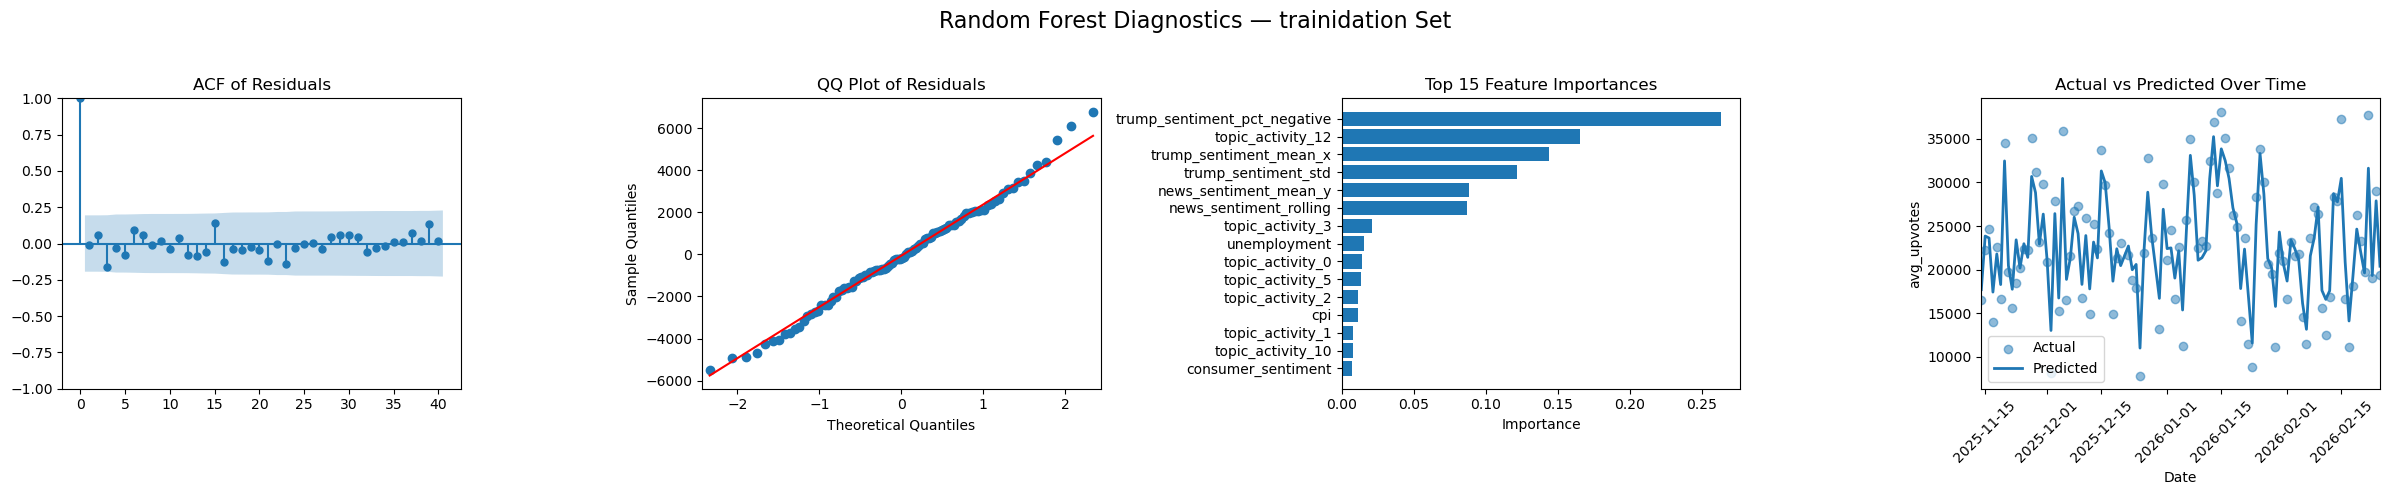

Target: total_upvotes
RMSE:   90864.804155
MAE:    61987.947059
R2:     0.880463


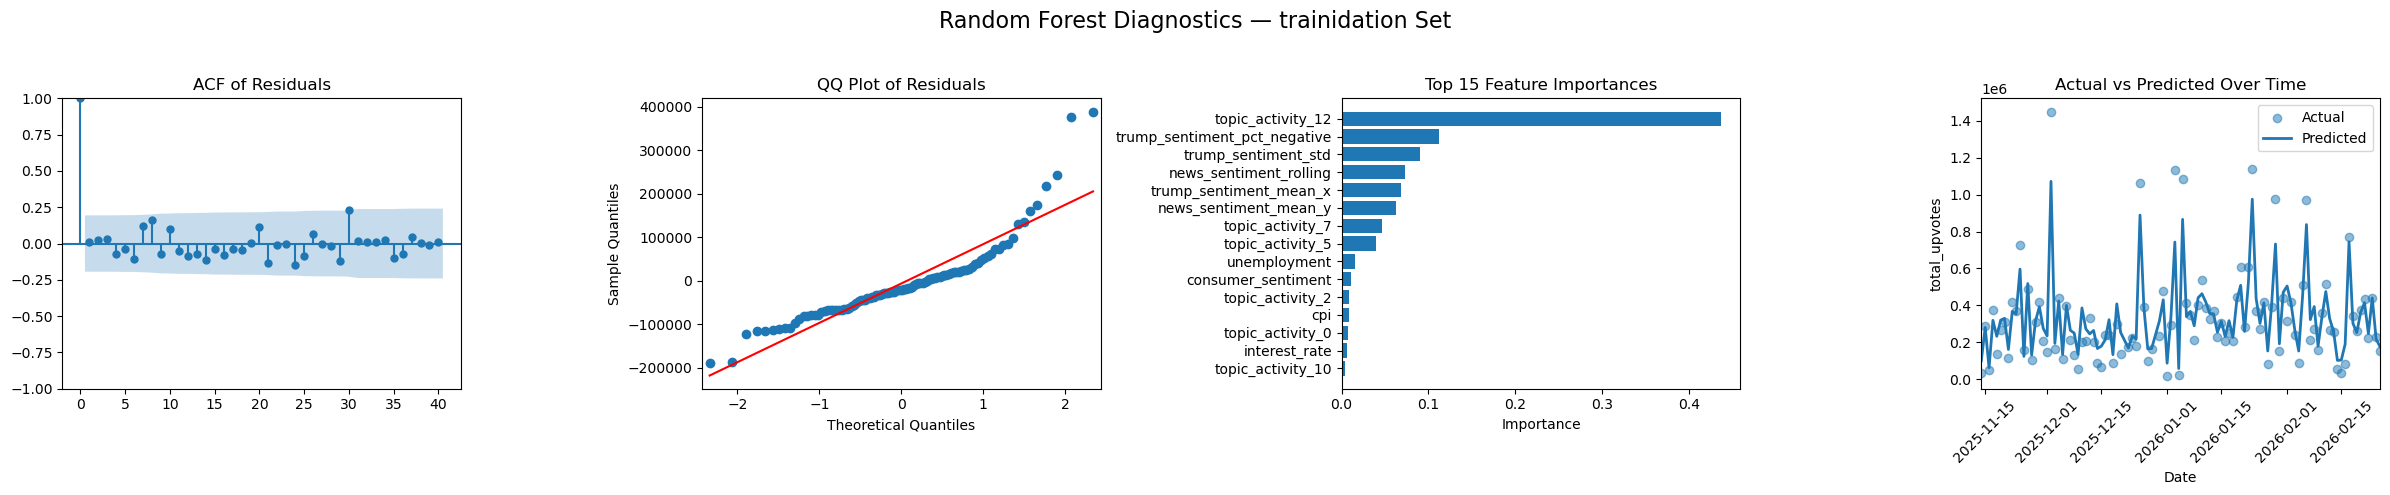

In [57]:
rf_model = results[
    [r["model_name"] for r in results].index("random_forest")
]["model"]

rf_train_diag = diagnose_random_forest(
    model=rf_model,
    X=X_train,
    Y=Y_train,
    time_data=df['date'],
    target_idx=0,
    lags=40,
    title="Random Forest Diagnostics — trainidation Set"
)

rf_train_diag = diagnose_random_forest(
    model=rf_model,
    X=X_train,
    Y=Y_train,
    time_data=df['date'],
    target_idx=1,
    lags=40,
    title="Random Forest Diagnostics — trainidation Set"
)

rf_train_diag = diagnose_random_forest(
    model=rf_model,
    X=X_train,
    Y=Y_train,
    time_data=df['date'],
    target_idx=2,
    lags=40,
    title="Random Forest Diagnostics — trainidation Set"
)

Target: avg_reblogs
RMSE:   1380.133916
MAE:    1199.014341
R2:     0.378028


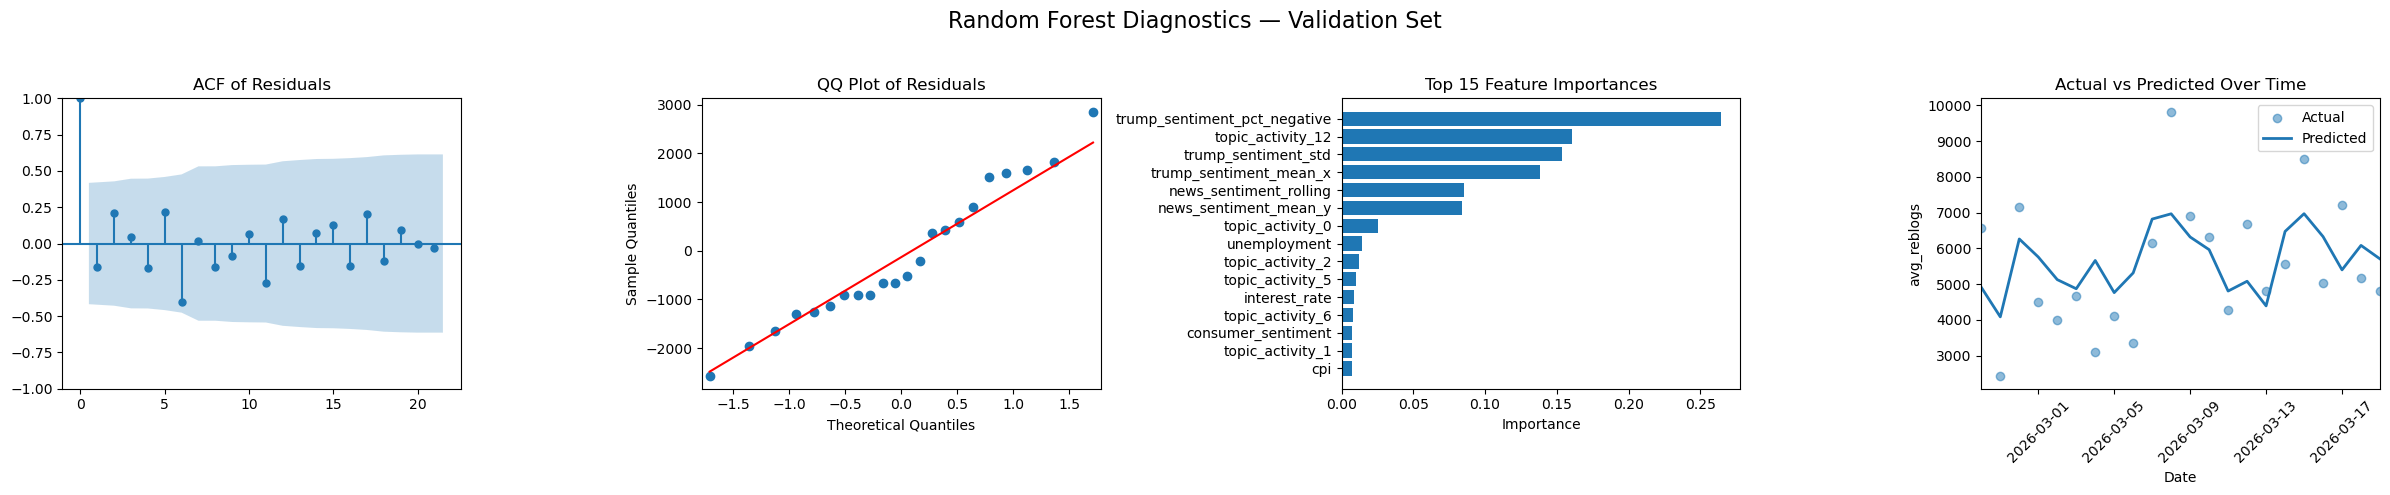

Target: avg_upvotes
RMSE:   5444.735180
MAE:    4343.263227
R2:     0.282166


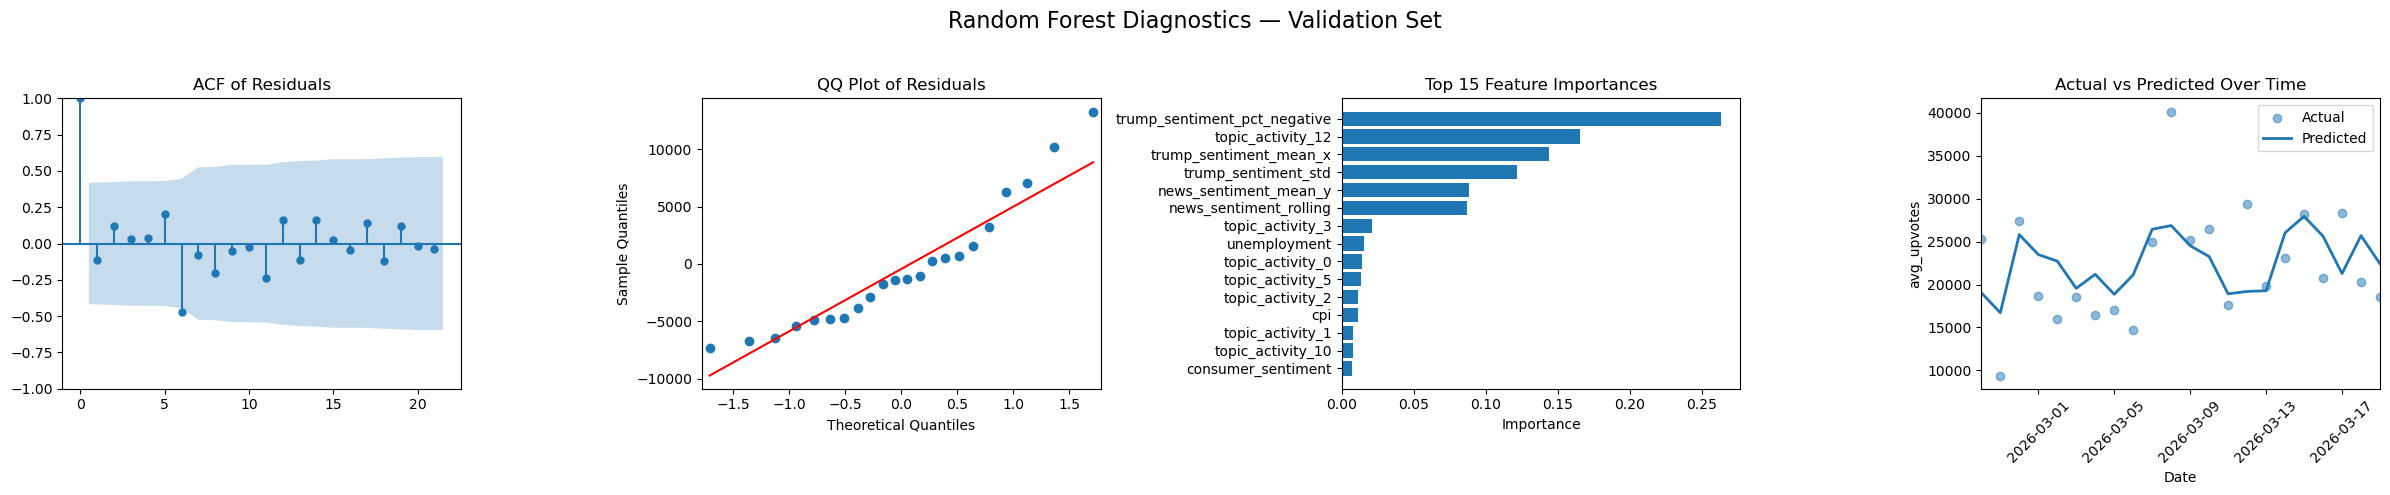

Target: total_upvotes
RMSE:   177921.257758
MAE:    132274.805227
R2:     0.153341


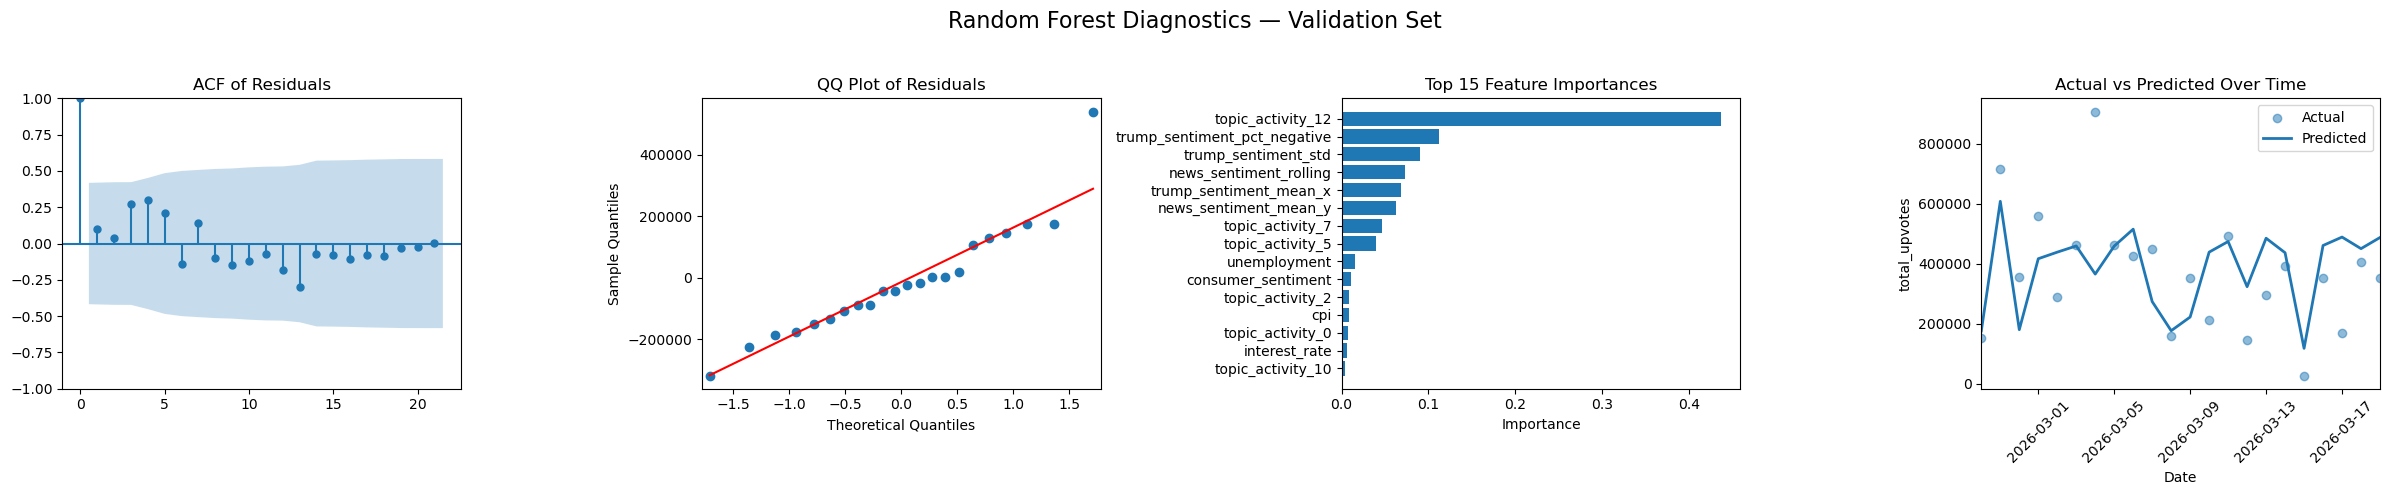

In [58]:
rf_val_diag = diagnose_random_forest(
    model=rf_model,
    X=X_val,
    Y=Y_val,
    time_data=df['date'],
    target_idx=0,
    lags=40,
    title="Random Forest Diagnostics — Validation Set"
)

rf_val_diag = diagnose_random_forest(
    model=rf_model,
    X=X_val,
    Y=Y_val,
    time_data=df['date'],
    target_idx=1,
    lags=40,
    title="Random Forest Diagnostics — Validation Set"
)

rf_val_diag = diagnose_random_forest(
    model=rf_model,
    X=X_val,
    Y=Y_val,
    time_data=df['date'],
    target_idx=2,
    lags=40,
    title="Random Forest Diagnostics — Validation Set"
)

We keep this code with no output if we need it for the presentaion, since these plots are a bit easier to see, but takes up too much space in a notebook

In [59]:
def shap_analysis_random_forest(
    model,
    X,
    target_idx=0,
    target_name=None,
    sample_size=500
):
    """
    Compute and display SHAP summary plot for a given target
    from a MultiOutput RandomForest model.
    """

    # Select a model and sample data
    if hasattr(model, "estimators_"):
        rf = model.estimators_[target_idx]
    else:
        rf = model
    if target_name is None:
        target_name = f"target_{target_idx}"
    if len(X) > sample_size:
        X_sample = X.sample(sample_size, random_state=42)
    else:
        X_sample = X.copy()

    # Compute shap
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_sample)

    # Plot
    print("=" * 80)
    print(f"SHAP Summary — {target_name}")
    print("=" * 80)

    shap.summary_plot(
        shap_values,
        X_sample,
        plot_size=(12, 6),
        show=True
    )

    return {
        "target": target_name,
        "shap_values": shap_values,
        "data": X_sample
    }
'''
shap_results = {}

for i, target_name in enumerate(Y_train.columns):
    shap_results[target_name] = shap_analysis_random_forest(
        model=rf_model,
        X=X_train,
        target_idx=i,
        target_name=target_name,
        sample_size=500
    )
'''

'\nshap_results = {}\n\nfor i, target_name in enumerate(Y_train.columns):\n    shap_results[target_name] = shap_analysis_random_forest(\n        model=rf_model,\n        X=X_train,\n        target_idx=i,\n        target_name=target_name,\n        sample_size=500\n    )\n'

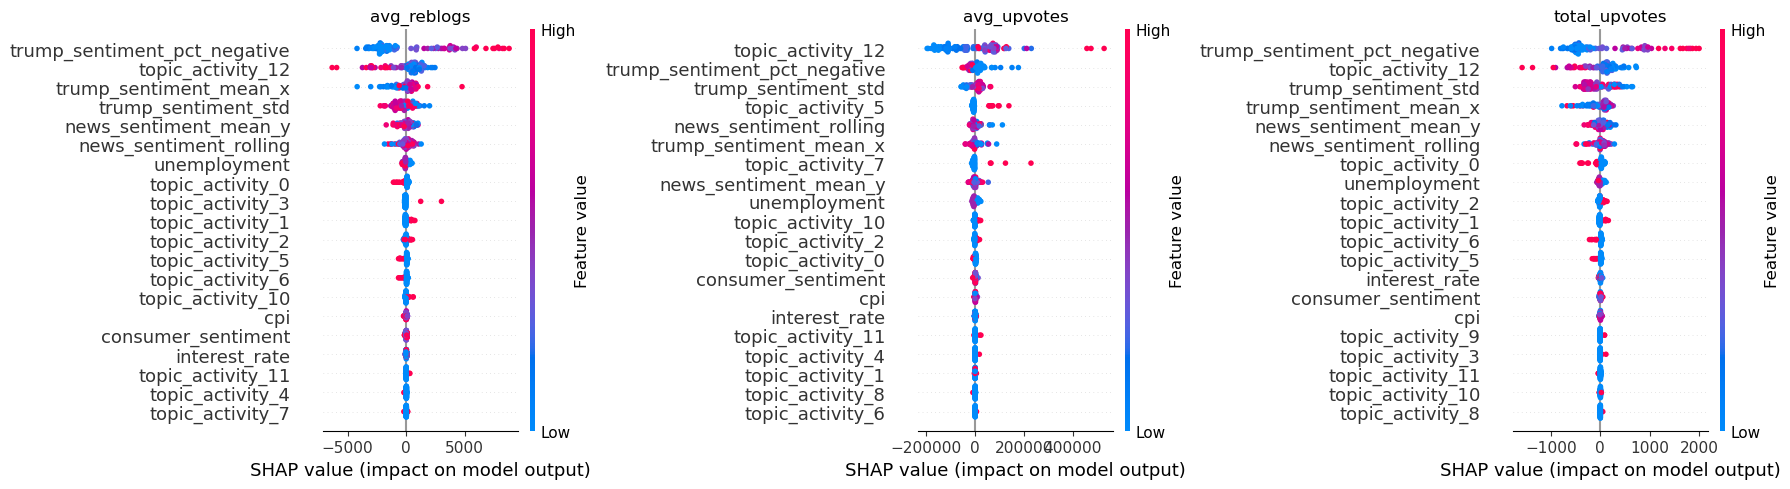

In [60]:
def shap_analysis_side_by_side(model, X, target_names, sample_size=500):
    """
    Plot SHAP summary plots for all targets side-by-side.
    """

    n_targets = len(target_names)

    # Sample data
    if len(X) > sample_size:
        X_sample = X.sample(sample_size, random_state=42)
    else:
        X_sample = X.copy()

    fig, axes = plt.subplots(1, n_targets, figsize=(6 * n_targets, 5))

    if n_targets == 1:
        axes = [axes]

    for i, (ax, target_name) in enumerate(zip(axes, target_names)):

        # Get model for target
        if hasattr(model, "estimators_"):
            rf = model.estimators_[i]
        else:
            rf = model

        # Compute SHAP
        explainer = shap.TreeExplainer(rf)
        shap_values = explainer.shap_values(X_sample)

        # Plot on specific axis
        shap.summary_plot(
            shap_values,
            X_sample,
            show=False,
            plot_size=None  
        )

        # Move plot to correct axis
        plt.sca(ax)
        ax.set_title(target_name)

    plt.tight_layout()
    plt.show()

shap_analysis_side_by_side(
    model=rf_model,
    X=X_train,
    target_names=list(Y_train.columns),
    sample_size=500
)